# **Lab 6 Hyperparameter Tuning**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset,Dataset

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os
import cv2
from skimage.util import random_noise
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

seed = 4912
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Data Preparation
Complete the class `CustomImageDataset()` that `__getitem__` return ***noisy blury*** image and ***ground truth*** image.
Please ensure that the final image is in RGBscale and has a size of 128x128.

In [2]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, gauss_noise=True, gauss_blur=True, resize=128, p=0.5):
        self.p = p
        self.resize = resize
        self.gauss_noise = gauss_noise
        self.gauss_blur = gauss_blur
        self.center_crop = transforms.CenterCrop(resize)
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def apply_gaussian_blur_and_noise(self, image):
        if self.gauss_blur:
            kernel_size = random.randrange(3, 12, 2)
            blur_image = transforms.GaussianBlur(kernel_size)(image)
        else:
            blur_image = image

        if self.gauss_noise:
            mask = np.random.rand(*image.shape) < self.p
            noisy_image = random_noise(blur_image, mode='gaussian', mean=np.random.uniform(-50, 50))
            noisy_image = np.where(mask, noisy_image, blur_image)
        else:
            noisy_image = blur_image

        return torch.from_numpy(noisy_image)


    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = plt.imread(image_path).transpose(2, 0, 1)
        gt_image = self.center_crop(torch.from_numpy(image.copy()))
        image = self.apply_gaussian_blur_and_noise(gt_image)

        return (image/255).float(), (gt_image/255).float()
### END CODE HERE ###

In [3]:
### START CODE HERE ###
def imshow_grid(images, title):
    fig, axs = plt.subplots(4, 4, figsize=(16,9))
    fig.suptitle(title)
    for i in range(4):
        for j in range(4):
            axs[i][j].imshow(np.array(images[i*4+j].permute(1,2,0)))
            axs[i][j].axis('off')
    fig.show()
### END CODE HERE ###

In [4]:
### START CODE HERE ###
from os import listdir
from os.path import isfile, join

data_dir = '/home/crueang/Chaks/image_processing-2024/data/img_align_celeba'

data = [join(data_dir, f) for f in listdir(data_dir) if isfile(join(data_dir, f))]
dataset = CustomImageDataset(image_paths=data)
dataloader = DataLoader(dataset, batch_size=16)
### END CODE HERE ###

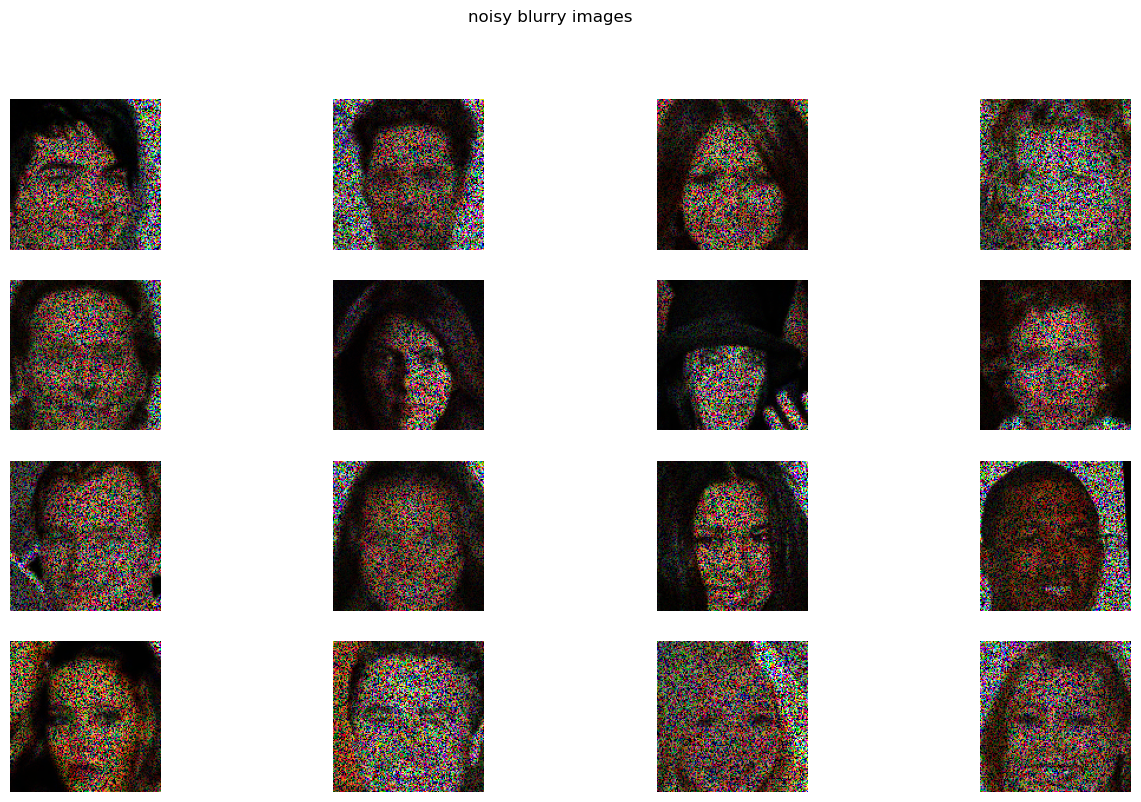

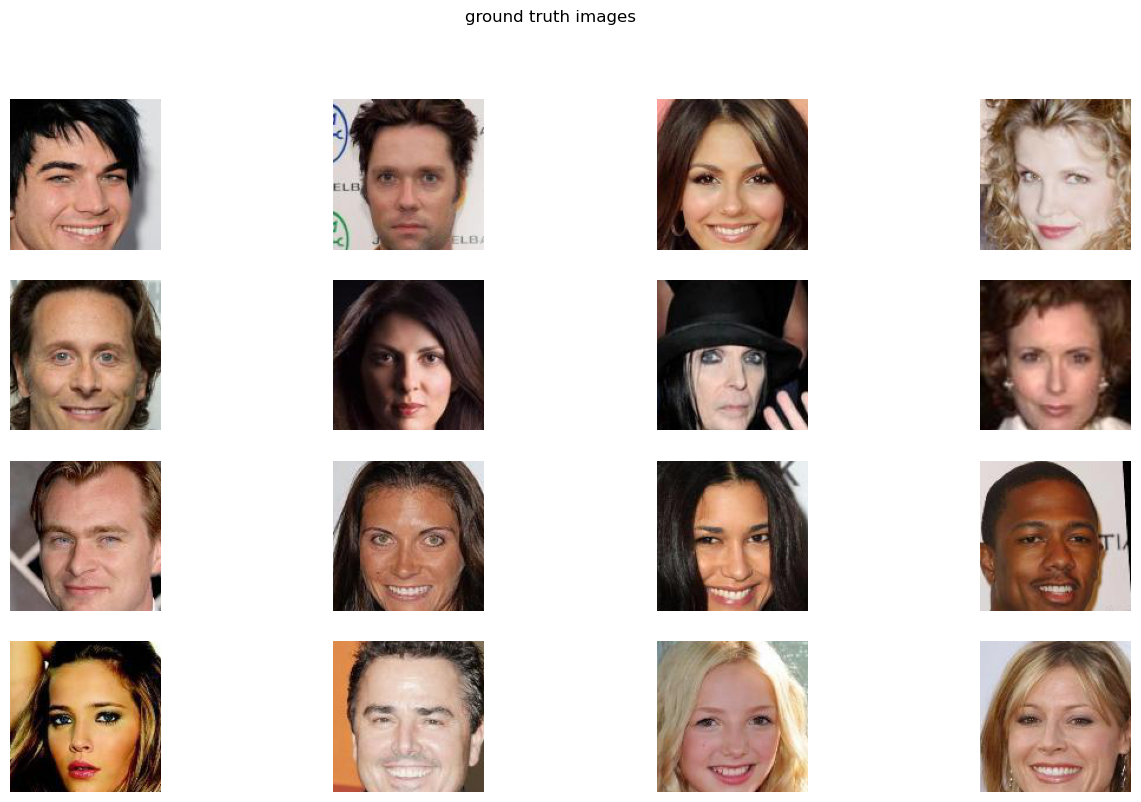

In [5]:
### START CODE HERE ###
batch, gt_img = next(iter(dataloader)) 

imshow_grid(batch, "noisy blurry images")
imshow_grid(gt_img, "ground truth images")

### END CODE HERE ###

## Create Autoencoder model
You can design your own Autoencoder model with a customizable number of downsampling and upsampling blocks by passing a list of channel numbers for each layer based on the provided code below. However, please maintain the concept of 'Autoencoder'.

In [6]:
### START CODE HERE ###
class DownSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DownSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class UpSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(UpSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.relu(x)
        x = self.upsample(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, channels=[64, 128, 256, 512, 1024]):
        super().__init__()
        self.conv_in = nn.Conv2d(3, channels[0], kernel_size=3, stride=1, padding=1)
        self.batch_norm = nn.BatchNorm2d(channels[0])
        self.relu = nn.ReLU()

        self.down = nn.ModuleList()
        for i in range(len(channels) - 1):
            self.down.append(DownSamplingBlock(channels[i], channels[i+1]))

        self.up = nn.ModuleList()
        for i in range(len(channels) - 1, 0, -1):
            self.up.append(UpSamplingBlock(channels[i], channels[i-1]))

        self.conv = nn.Conv2d(channels[0], 3, kernel_size=3, stride=1, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        downs = []
        x = self.conv_in(x)
        x = self.batch_norm(x)
        x = self.relu(x)
        downs.append(x)

        for down_layer in self.down:
            x = down_layer(x)
            downs.append(x)

        for i, up_layer in enumerate(self.up):
            x = up_layer(x)
            x = x + downs[-(i+2)]

        x = self.conv(x + downs[0])
        x = self.sigmoid(x)

        return x
### END CODE HERE ###

## Train Autoencoder
Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the ***training loss, test loss,test PSNR, test SSIM***. Additionally, it should save the model at the last epoch.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The log should resemble this, but not be identical

```
🤖Training on cuda
🚀Training Epoch [1/1]: 100%|██████████| 1313/1313 [01:45<00:00, 12.41batch/s, loss=0.0102] 
📄Testing: 100%|██████████| 563/563 [01:10<00:00,  7.95batch/s, loss=0.0106, psnr=16.7, ssim=0.348] 
Summary :
	Train	avg_loss: 0.017262999383663165
	Test	avg_loss: 0.010476540363861867 
                PSNR : 16.839487147468034 
                SSIM : 0.36090552368883694
...
```

</details>

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [PSNR & SSIM](https://ieeexplore.ieee.org/document/5596999)

In [7]:
### START CODE HERE ###
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

def train(model, opt, loss_fn, train_loader, test_loader, epochs=10, checkpoint_path=None, device='cpu'):
    def compute_psnr(batch1, batch2):
      psnr = PeakSignalNoiseRatio().to(device)
      return float(psnr(batch1, batch2))

    def compute_ssim(img1, img2):
      ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
      ssim_value = ssim(img1, img2)
      return float(ssim_value)

    training_logs = {"train_loss": [], "validate_loss": [], "PSNR": [], "SSIM": []}
    epoch_number = 0
    best_test_loss = float('inf')
    model = model.to(device)

    if checkpoint_path:
      if os.path.exists(checkpoint_path + 'model.pth'):
        model.load_state_dict(torch.load(checkpoint_path + 'model.pth', weights_only=True, map_location=device))

      if os.path.exists(checkpoint_path + 'opt.pth'):
        opt.load_state_dict(torch.load(checkpoint_path + 'opt.pth', weights_only=True, map_location=device))

      if os.path.exists(checkpoint_path + 'training_logs.pth'):
        training_logs = torch.load(checkpoint_path + 'training_logs.pth', weights_only=True)
        epoch_number = len(training_logs['train_loss'])
        best_test_loss = min(best_test_loss, min(training_logs['validate_loss']))

    for i in range(epoch_number):
        print(f"Epochs {i+1}".ljust(10),
                f"train loss: {training_logs['train_loss'][i]:.5f}",
                f"validate loss: {training_logs['validate_loss'][i]:.5f}",
                f"PSNR: {training_logs['PSNR'][i]:.5f}",
                f"SSIM: {training_logs['SSIM'][i]:.5f}"
                )

    print("🤖Training on", device)
    for epoch in range(epoch_number, epochs):

        train_loss = 0
        model.train()
        train_bar = tqdm(train_loader, desc=f'🚀Training Epoch [{epoch+1}/{epochs}]', unit='batch')
        for images, gt in train_bar:
            images = images.to(device)
            gt = gt.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, gt)
            loss.backward()
            opt.step()

            train_loss += loss.item()
        print(f'\n\tTrain loss: {train_loss/len(train_loader)}')
        training_logs["train_loss"].append(train_loss / len(train_loader))

        test_loss, psnr, ssim = 0, 0, 0
        model.eval()
        test_bar = tqdm(test_loader,desc='📄Testing',unit='batch')
        with torch.no_grad():
          for images, gt in test_bar:
            images = images.to(device)
            gt = gt.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, gt)

            psnr += compute_psnr(outputs, gt)
            ssim += compute_ssim(outputs, gt)
            test_loss += loss.item()
        avg_test_loss = test_loss/len(test_loader)
        print(f'\tTest loss: {avg_test_loss}')
        training_logs["validate_loss"].append(avg_test_loss)
        training_logs["PSNR"].append(psnr / len(test_loader))
        training_logs["SSIM"].append(ssim / len(test_loader))

        if checkpoint_path:
            torch.save(model.state_dict(), checkpoint_path + "model.pth")
            torch.save(opt.state_dict(), checkpoint_path + "opt.pth")
            torch.save(training_logs, checkpoint_path + 'training_logs.pth')
            if best_test_loss > avg_test_loss:
               torch.save(model.state_dict(), checkpoint_path + "best_model.pth")
               best_test_loss = avg_test_loss

### END CODE HERE ###

Let's train your model with 2 epochs to verify that your train() function works properly. After that, we'll move on to the Hyperparameter Grid Search in the next part.

In [8]:
### START CODE HERE ###
data_dir = '/home/crueang/Chaks/image_processing-2024/data/img_align_celeba'

data = [join(data_dir, f) for f in listdir(data_dir) if isfile(join(data_dir, f))]
tiny_data = random.sample(data, 1000)
print(len(tiny_data))

# Split the dataset into training and testing sets
train_files, test_files = train_test_split(tiny_data, test_size=0.2, random_state=42)

train_dataset = CustomImageDataset(train_files)
test_dataset = CustomImageDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)
### END CODE HERE ###

1000


In [9]:
### START CODE HERE ###
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Autoencoder()
opt = optim.Adam(model.parameters(), lr=1e-5)
loss_fn = nn.MSELoss()
train(model, opt, loss_fn, train_loader, test_loader, epochs=2, checkpoint_path="/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/cp", device=device)
### END CODE HERE ###

Epochs 1   train loss: 0.01677 validate loss: 0.00850 PSNR: 20.71478 SSIM: 0.42366
Epochs 2   train loss: 0.00758 validate loss: 0.00592 PSNR: 22.28767 SSIM: 0.49949
🤖Training on cpu


---

## **Hyperparameter Grid Search with Raytune**

*If you have access to APEX, I would recommend converting this part into a Python file and submitting the job to run on APEX using SBATCH. This process may take a considerable amount of time.*

You can import additional Ray Tune tools as you want, such as schedulers, search algorithms, etc. Further information on the usage of Ray Tune can be found [here](https://docs.ray.io/en/latest/tune/index.html).

In [10]:
import ray
from ray import tune
from ray.air import session

ray.shutdown()

Complete the `train_raytune()` function below, following the [quick start guide](https://docs.ray.io/en/latest/tune/index.html). This function will be passed to the `tune.Tuner`.

In [11]:
### START CODE HERE ###
from ray.train import Checkpoint
from math import log10

def train_raytune(config):

    def compute_psnr(mse):
      return -10 * log10(mse)

    def compute_ssim(images1, images2):
        ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
        return ssim_metric(images1, images2).item()
    
    torch.cuda.empty_cache()

    trainloader = config['dataloader'][0].trainloader
    testloader = config['dataloader'][0].testloader
    
    # trainloader = DataLoader(train_dataset, batch_size=config['dataloader'])
    # testloader = DataLoader(test_dataset, batch_size=config['dataloader'])

    model = Autoencoder(config['architecture'])
    model = model.to(device)
    loss_fn = torch.nn.MSELoss()

    if config['optimizer'] == 'Adam':
        opt = optim.Adam(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'SGD':
        opt = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)

    # Training loop
    for epoch in range(0, config['num_epochs']):
        train_loss = 0
        for images, gt in trainloader:
            images = images.to(device)
            gt = gt.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, gt)
            loss.backward()
            opt.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(trainloader)
        torch.cuda.empty_cache()

        # Evaluation
        val_loss, total_ssim, total_psnr = 0, 0, 0
        model.eval()
        with torch.no_grad():
            for images, gt in testloader:
                images = images.to(device)
                gt = gt.to(device)
                outputs = model(images)
                
                loss = loss_fn(outputs, gt)

                total_psnr += compute_psnr(loss.item())
                total_ssim += compute_ssim(outputs, gt)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(testloader)
        avg_psnr = total_psnr / len(testloader)
        avg_ssim = total_ssim / len(testloader)

        # Report metrics to Ray Tune
        metrics = {
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_psnr": avg_psnr,
            "val_ssim": avg_ssim,
        }

        session.report(metrics)

### END CODE HERE ###

In [12]:
device = 'cuda'
config = {
    'dataloader': dataloader_16,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'num_epochs': 1,
    'architecture': [64, 128, 256]
}
train_raytune(config)

NameError: name 'dataloader_16' is not defined

In [33]:
torch.cuda.empty_cache()

Initialize Ray, define the search space, and resources.

Resource : 
- [A Guide To Parallelism and Resources for Ray Tune](https://docs.ray.io/en/latest/tune/tutorials/tune-resources.html#:~:text=A%20Guide%20To%20Parallelism%20and%20Resources%20for%20Ray%20Tune) 
- [Working with Tune Search Spaces](https://docs.ray.io/en/latest/tune/tutorials/tune-search-spaces.html#tune-search-space-tutorial:~:text=Working%20with%20Tune%20Search%20Spaces)
- [How to configure logging in Tune?](https://docs.ray.io/en/latest/tune/tutorials/tune-output.html) 
- [Tune Trial Schedulers (`tune.schedulers`)](https://docs.ray.io/en/latest/tune/api/schedulers.html#tune-scheduler-pbt:~:text=Tune%20Trial...-,Tune%20Trial%20Schedulers%20(tune.schedulers),-%23)

**Search Space:**
- `architecture`:<br>
    Feature map dimensions for convolutional layers<br>
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with more depth, starting from 64 and ending at 512.
- `learning rates (lr)`:
    - [1e-3, 8e-4, 1e-4, 1e-2]: Test a wide range of learning rates to evaluate model performance, from 1e-3 (typical) to a more aggressive 1e-2 or conservative 1e-4.
- `batch size`:
    - [16, 32]: Explore smaller batch sizes to evaluate their impact on gradient estimation and memory usage.
- `number of epochs`:
    - `[10, 50, 100]`: Allow short and long training sessions, from quick evaluations (10 epochs) to more extensive training (100 epochs).
- `optimizers (opts)`:
    - `["Adam", "SGD"]`: Compare two popular optimization algorithms: Adam for adaptive learning rates and SGD for momentum-based updates.

In [66]:
class CustomDataloader:
    def __init__(self, batch_size):
        self.trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.testloader = DataLoader(test_dataset, batch_size=batch_size)
        self.batch_size = batch_size
    
    def __str__(self) -> str:
        return str(self.batch_size)
    
    def __repr__(self) -> str:
        return str(self.batch_size)

dataloader_16 = CustomDataloader(16)
dataloader_32 = CustomDataloader(32)

In [68]:
### START CODE HERE ###
from ray.tune.schedulers import ASHAScheduler
from ray.train import RunConfig

ray.shutdown()
ray.init(num_gpus=1, num_cpus=5)

def generate_trial_name(trial):
    _, batch_size = trial.config['dataloader']
    optimizer = trial.config['optimizer']
    lr = trial.config['lr']
    num_epochs = trial.config['num_epochs']
    architecture = trial.config['architecture']
    return f"trial_{trial.trial_id}_bs_{batch_size}_opt_{optimizer}_lr_{lr}_epochs_{num_epochs}_arch_{architecture}"

config = {
    'dataloader': tune.grid_search([(CustomDataloader(16), 16), (CustomDataloader(32), 32)]),
    'optimizer': tune.grid_search(['Adam', 'SGD']),
    'lr': tune.grid_search([1e-3, 8e-4, 1e-4, 1e-2]),
    'num_epochs': tune.grid_search([10, 50, 100]),
    'architecture': tune.grid_search([[32, 64, 128], [64, 128, 256], [64, 128, 256, 512]])
}

tuner = tune.Tuner(
    tune.with_resources(
        train_raytune,
        resources={"gpu": 1, 'cpu': 1}
    ),
    tune_config = tune.TuneConfig(
        metric = 'val_psnr',
        mode = 'max',
        scheduler = ASHAScheduler(),
        trial_name_creator=generate_trial_name
    ),
    param_space = config,
    run_config = RunConfig(
        storage_path="/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/ray_restore",
        name="grid_search",
    )
)

# result = tuner.fit()

### END CODE HERE ###

Restore the result from path of ray resule directory

In [4]:
from ray import tune

In [5]:
### START CODE HERE ###
path = "/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/ray_restore/grid_search"
restored_tuner = tune.Tuner.restore(path, trainable='train_raytune')
result = restored_tuner.get_results()
### END CODE HERE ###

Get the report from Grid Search to CSV file.

In [8]:
print("🎉[INFO] Training is done!")
print("Best config is:", result.get_best_result().config)
print("Best result is:", result.get_best_result())
df = result.get_dataframe()

print(df.nlargest(3, 'val_psnr')[['val_psnr', 'config/dataloader', 'config/optimizer', 'config/lr', 'config/num_epochs', 'config/architecture']])

🎉[INFO] Training is done!
Best config is: {'dataloader': [16, 16], 'optimizer': 'Adam', 'lr': 0.001, 'num_epochs': 100, 'architecture': [64, 128, 256, 512]}
Best result is: Result(
  metrics={'train_loss': 0.0012123165151569993, 'val_loss': 0.0011323685802590961, 'val_psnr': 29.51888851867939, 'val_ssim': 0.8770757088294396},
  path='/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/ray_restore/grid_search/trial_eb4c3_00050_bs_16_opt_Adam_lr_0.001_epochs_100_arch_[64, 128, 256, 512]_50_architecture=64_128_256_512,dataloader=ref_ph_c68_2024-09-17_04-44-59',
  filesystem='local',
  checkpoint=None
)
     val_psnr config/dataloader config/optimizer  config/lr  \
53  29.518889          [16, 16]             Adam     0.0010   
15  27.799257          [16, 16]             Adam     0.0008   
10  27.527953          [16, 16]             Adam     0.0100   

    config/num_epochs  config/architecture  
53                100  [64, 128, 256, 512]  
15                 50  [64, 128, 

---

Train the Autoencoder models using the best hyperparameter set obtained from the grid search.

In [13]:
data_dir = '/home/crueang/Chaks/image_processing-2024/data/img_align_celeba'

data = [join(data_dir, f) for f in listdir(data_dir) if isfile(join(data_dir, f))]
# tiny_data = random.sample(data, 1000)
# print(len(tiny_data))

# Split the dataset into training and testing sets
train_files, test_files = train_test_split(data, test_size=0.2, random_state=42)

train_dataset = CustomImageDataset(train_files)
test_dataset = CustomImageDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [77]:
### START CODE HERE ###
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Autoencoder([64, 128, 256, 512]).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train(model, opt, loss_fn, train_loader, test_loader, epochs=100, checkpoint_path="/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/cp/grid_search/", device=device)

### END CODE HERE ###

Epochs 1   train loss: 0.00450 validate loss: 0.00220 PSNR: 26.60621 SSIM: 0.78161
Epochs 2   train loss: 0.00262 validate loss: 0.00205 PSNR: 26.90711 SSIM: 0.82063
Epochs 3   train loss: 0.00206 validate loss: 0.00166 PSNR: 27.84707 SSIM: 0.84949
Epochs 4   train loss: 0.00174 validate loss: 0.00169 PSNR: 27.74560 SSIM: 0.86129
Epochs 5   train loss: 0.00154 validate loss: 0.00139 PSNR: 28.62138 SSIM: 0.87172
Epochs 6   train loss: 0.00143 validate loss: 0.00128 PSNR: 28.96348 SSIM: 0.87902
Epochs 7   train loss: 0.00132 validate loss: 0.00121 PSNR: 29.21636 SSIM: 0.88409
Epochs 8   train loss: 0.00125 validate loss: 0.00111 PSNR: 29.60383 SSIM: 0.88796
Epochs 9   train loss: 0.00117 validate loss: 0.00111 PSNR: 29.60655 SSIM: 0.89281
Epochs 10  train loss: 0.00113 validate loss: 0.00101 PSNR: 30.00066 SSIM: 0.89631
Epochs 11  train loss: 0.00109 validate loss: 0.00108 PSNR: 29.70552 SSIM: 0.89735
Epochs 12  train loss: 0.00105 validate loss: 0.00110 PSNR: 29.64315 SSIM: 0.89912
Epoc

/tmp/ipykernel_3897496/4247120565.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/home/crueang/Chaks/image_processing-2024/Lab6_Hyperp

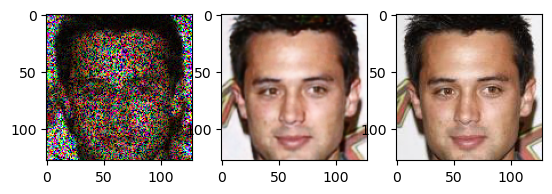

In [71]:
### START CODE HERE ###
model = Autoencoder([64, 128, 256, 512])
model.load_state_dict(torch.load('/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/cp/grid_search/best_model.pth', map_location='cpu'))
dataset = CustomImageDataset(image_paths=['/home/crueang/Chaks/image_processing-2024/data/img_align_celeba/000007.jpg'])
dataloader = DataLoader(dataset)
batch, gt_img = next(iter(dataloader))

fig, axs = plt.subplots(1, 3)
axs[0].imshow(batch[0].permute(1, 2, 0))
axs[1].imshow(model(batch)[0].detach().permute(1, 2, 0))
axs[2].imshow(gt_img[0].permute(1, 2, 0))
### END CODE HERE ###

Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers. Then, save it as an image.


In [68]:
import math
class FeatureMapVisualizer:
    def __init__(self, model, layers, save_dir):
        """
        Parameters:
        - model: The PyTorch model
        - layers: A string or list of strings specifying the layer names to visualize
        - save_dir: Directory to save the output feature map images
        """
        self.model = model
        self.layers = layers if isinstance(layers, list) else [layers]
        self.activations = {}
        self.save_dir = save_dir

        os.makedirs(self.save_dir, exist_ok=True)

        self._register_hooks()

    def _register_hooks(self):
        for name, layer in self.model.named_modules():
            if name in self.layers:
                layer.register_forward_hook(self._hook_fn(name))

    def _hook_fn(self, layer_name):
        def hook(module, input, output):
            print(f'Hooking layer: {layer_name}')
            self.activations[layer_name] = output.detach()
        return hook

    def visualize(self, input_paths):
        """
        Pass an input tensor through the model and visualize the activations.
        
        Parameters:
        - input_paths: List of image paths to pass through the model
        """
        
        for img_path in input_paths:
            self.model(img_path)

            for layer_name, activation in self.activations.items():
                print(f'Visualizing and saving layer: {layer_name}')
                self._save_feature_maps(activation, layer_name)

    def _save_feature_maps(self, activation, layer_name):
        ### START CODE HERE ###
        num_channels = activation.shape[1]
        grid_size = int(np.ceil(np.sqrt(num_channels)))
        
        fig, axs = plt.subplots(grid_size, grid_size, figsize=(15, 15))
        fig.suptitle(f'Feature Map {layer_name}', fontsize=16)
        fig.tight_layout()
        
        for j in range(num_channels):
            ax = axs[j // grid_size, j % grid_size]
            ax.imshow(self.activations[layer_name][0, j, :, :], cmap='gray')
            ax.axis('off')
            ax.set_title(f'ch {j+1}', fontsize=8)

        for j in range(num_channels, grid_size * grid_size):
            axs[j // grid_size, j % grid_size].axis('off')
        
        fig.savefig(f'{self.save_dir}{layer_name}.jpg')
        
        ### END CODE HERE ###

In [ ]:
### START CODE HERE ###

layer = [name for name, layer in model.named_modules() if 'relu' in name]
visualizer = FeatureMapVisualizer(model, layer,
                                  "/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/outputs/grid_search/")
visualizer.visualize([batch])


### END CODE HERE ###

---
## **Hyperparameter Random Search with Raytune**

**Search Space:**

- **`architecture`:**  
    Define the feature map dimensions for convolutional layers:  
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with additional depth, starting from 64 and ending at 512.
  
- **`learning rates (lr)`**:  
    A continuous range of learning rates sampled uniformly between `1e-4` and `1e-2`. This allows exploration of different learning rates from conservative (`1e-4`) to more aggressive (`1e-2`) values.

- **`batch size`**:  
    Randomly sample an integer batch size between 16 and 32 (inclusive). This allows testing of smaller batch sizes, which can affect gradient estimation and memory usage.

- **`number of epochs`**:  
    Randomly sample an integer number of epochs between 10 and 100. This allows the model to train for short (e.g., 10 epochs) or extended periods (up to 100 epochs), giving insight into model performance over different training durations.

- **`optimizers (opts)`**:  
    Randomly select between two optimizers:  
    - `"Adam"`: An adaptive learning rate optimizer that generally performs well across various tasks.  
    - `"SGD"`: Stochastic Gradient Descent with momentum, commonly used for large-scale tasks, requiring careful tuning of the learning rate.

***NOTE*** Random search with 80 samples.

In [73]:
### START CODE HERE ###
# ray.shutdown()
# ray.init(num_gpus=1)

from ray.tune.schedulers import ASHAScheduler

config = {
    'dataloader': tune.choice([(CustomDataloader(16), 16), (CustomDataloader(32), 32)]),
    'optimizer': tune.choice(['Adam', 'SGD']),
    'lr': tune.loguniform(1e-4, 1e-2),
    'num_epochs': tune.randint(10, 101),
    'architecture': tune.choice([[32, 64, 128], [64, 128, 256], [64, 128, 256, 512]])
}

tuner = tune.Tuner(
    tune.with_resources(
        train_raytune,
        resources={"gpu": 1}
    ),
    tune_config = tune.TuneConfig(
        metric = 'val_psnr',
        mode = 'max',
        num_samples = 80,
        scheduler = ASHAScheduler(),
        trial_name_creator=generate_trial_name
    ),
    param_space = config,
    run_config = RunConfig(
        storage_path="/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/ray_restore",
        name="random_search",
    )
)

# result = tuner.fit()

### END CODE HERE ###

2024-09-17 09:33:31,411	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'dataloader': (('__ref_ph', 'c68ca31f'), 16)}
2024-09-17 09:33:44,594	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'dataloader': (('__ref_ph', 'c68ca31f'), 16)}
2024-09-17 09:39:58,164	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'dataloader': (('__ref_ph', 'c68ca31f'), 16)}
2024-09-17 09:40:11,168	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'dataloader': (('__ref_ph', 'c68ca31f'), 16)}
2024-09-17 09:40:23,953	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'dataloader': (('__ref_ph', 'c68ca31f'), 16)}
2024-09-17 09:40:36,941	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'dataloader': 

In [13]:
path = "/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/ray_restore/random_search"
restored_tuner = tune.Tuner.restore(path, trainable='train_raytune')
result = restored_tuner.get_results()

In [14]:
print("🎉[INFO] Training is done!")
print("Best config is:", result.get_best_result().config)
print("Best result is:", result.get_best_result())
df = result.get_dataframe()

print(df['val_psnr'].nlargest(3))

print(df.nlargest(3, 'val_psnr')[['val_psnr', 'config/dataloader', 'config/optimizer', 'config/lr', 'config/num_epochs', 'config/architecture']])

# ray.shutdown()

🎉[INFO] Training is done!
Best config is: {'dataloader': [16, 16], 'optimizer': 'Adam', 'lr': 0.0008256736602329388, 'num_epochs': 79, 'architecture': [64, 128, 256]}
Best result is: Result(
  metrics={'train_loss': 0.0013260961254127324, 'val_loss': 0.0013088836209275401, 'val_psnr': 28.895255520674773, 'val_ssim': 0.8654355085813082},
  path='/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/ray_restore/random_search/trial_f4c7b_00002_bs_16_opt_Adam_lr_0.0008256736602329388_epochs_79_arch_[64, 128, 256]_2_architecture=64_128_256,dataloader=ref_p_2024-09-17_09-31-34',
  filesystem='local',
  checkpoint=None
)
47    28.895256
12    28.793393
18    28.677751
Name: val_psnr, dtype: float64
     val_psnr config/dataloader config/optimizer  config/lr  \
47  28.895256          [16, 16]             Adam   0.000826   
12  28.793393          [16, 16]             Adam   0.002176   
18  28.677751          [16, 16]             Adam   0.002273   

    config/num_epochs  config/a

---

Train the Autoencoder models using the best hyperparameter set obtained from the random search.

In [73]:
### START CODE HERE ###
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Autoencoder([64, 128, 256]).to(device)
opt = optim.Adam(model.parameters(), lr=0.0008256736602329388)
loss_fn = nn.MSELoss()
train(model, opt, loss_fn, train_loader, test_loader, epochs=79, checkpoint_path="/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/cp/random_search/", device=device)

### END CODE HERE ###

Epochs 1   train loss: 0.00450 validate loss: 0.00294 PSNR: 25.34142 SSIM: 0.76848
Epochs 2   train loss: 0.00261 validate loss: 0.00223 PSNR: 26.54105 SSIM: 0.81312
Epochs 3   train loss: 0.00213 validate loss: 0.00187 PSNR: 27.32206 SSIM: 0.83487
Epochs 4   train loss: 0.00187 validate loss: 0.00159 PSNR: 28.01494 SSIM: 0.85054
Epochs 5   train loss: 0.00168 validate loss: 0.00148 PSNR: 28.33791 SSIM: 0.85882
Epochs 6   train loss: 0.00153 validate loss: 0.00140 PSNR: 28.57261 SSIM: 0.86526
Epochs 7   train loss: 0.00143 validate loss: 0.00150 PSNR: 28.27447 SSIM: 0.86779
Epochs 8   train loss: 0.00135 validate loss: 0.00147 PSNR: 28.36551 SSIM: 0.87070
Epochs 9   train loss: 0.00129 validate loss: 0.00133 PSNR: 28.79510 SSIM: 0.87894
Epochs 10  train loss: 0.00124 validate loss: 0.00126 PSNR: 29.04643 SSIM: 0.88285
Epochs 11  train loss: 0.00120 validate loss: 0.00122 PSNR: 29.17791 SSIM: 0.88050
Epochs 12  train loss: 0.00116 validate loss: 0.00115 PSNR: 29.43521 SSIM: 0.88681
Epoc

Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers of the Convolution Feature Extractor part. Then, save it as an image.

/tmp/ipykernel_3897496/1763649649.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/home/crueang/Chaks/image_processing-2024/Lab6_Hyperp

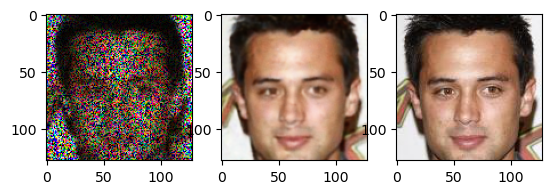

In [74]:
### START CODE HERE ###
model = Autoencoder([64, 128, 256])
model.load_state_dict(torch.load('/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/cp/random_search/best_model.pth', map_location='cpu'))
dataset = CustomImageDataset(image_paths=['/home/crueang/Chaks/image_processing-2024/data/img_align_celeba/000007.jpg'])
dataloader = DataLoader(dataset)
batch, gt_img = next(iter(dataloader))

fig, axs = plt.subplots(1, 3)
axs[0].imshow(batch[0].permute(1, 2, 0))
axs[1].imshow(model(batch)[0].detach().permute(1, 2, 0))
axs[2].imshow(gt_img[0].permute(1, 2, 0))
### END CODE HERE ###

Hooking layer: relu
Hooking layer: relu
Hooking layer: down.0.relu
Hooking layer: down.0.relu
Hooking layer: down.1.relu
Hooking layer: down.1.relu
Hooking layer: up.0.relu
Hooking layer: up.0.relu
Hooking layer: up.1.relu
Hooking layer: up.1.relu
Visualizing and saving layer: relu


Visualizing and saving layer: down.0.relu
Visualizing and saving layer: down.1.relu
Visualizing and saving layer: up.0.relu
Visualizing and saving layer: up.1.relu


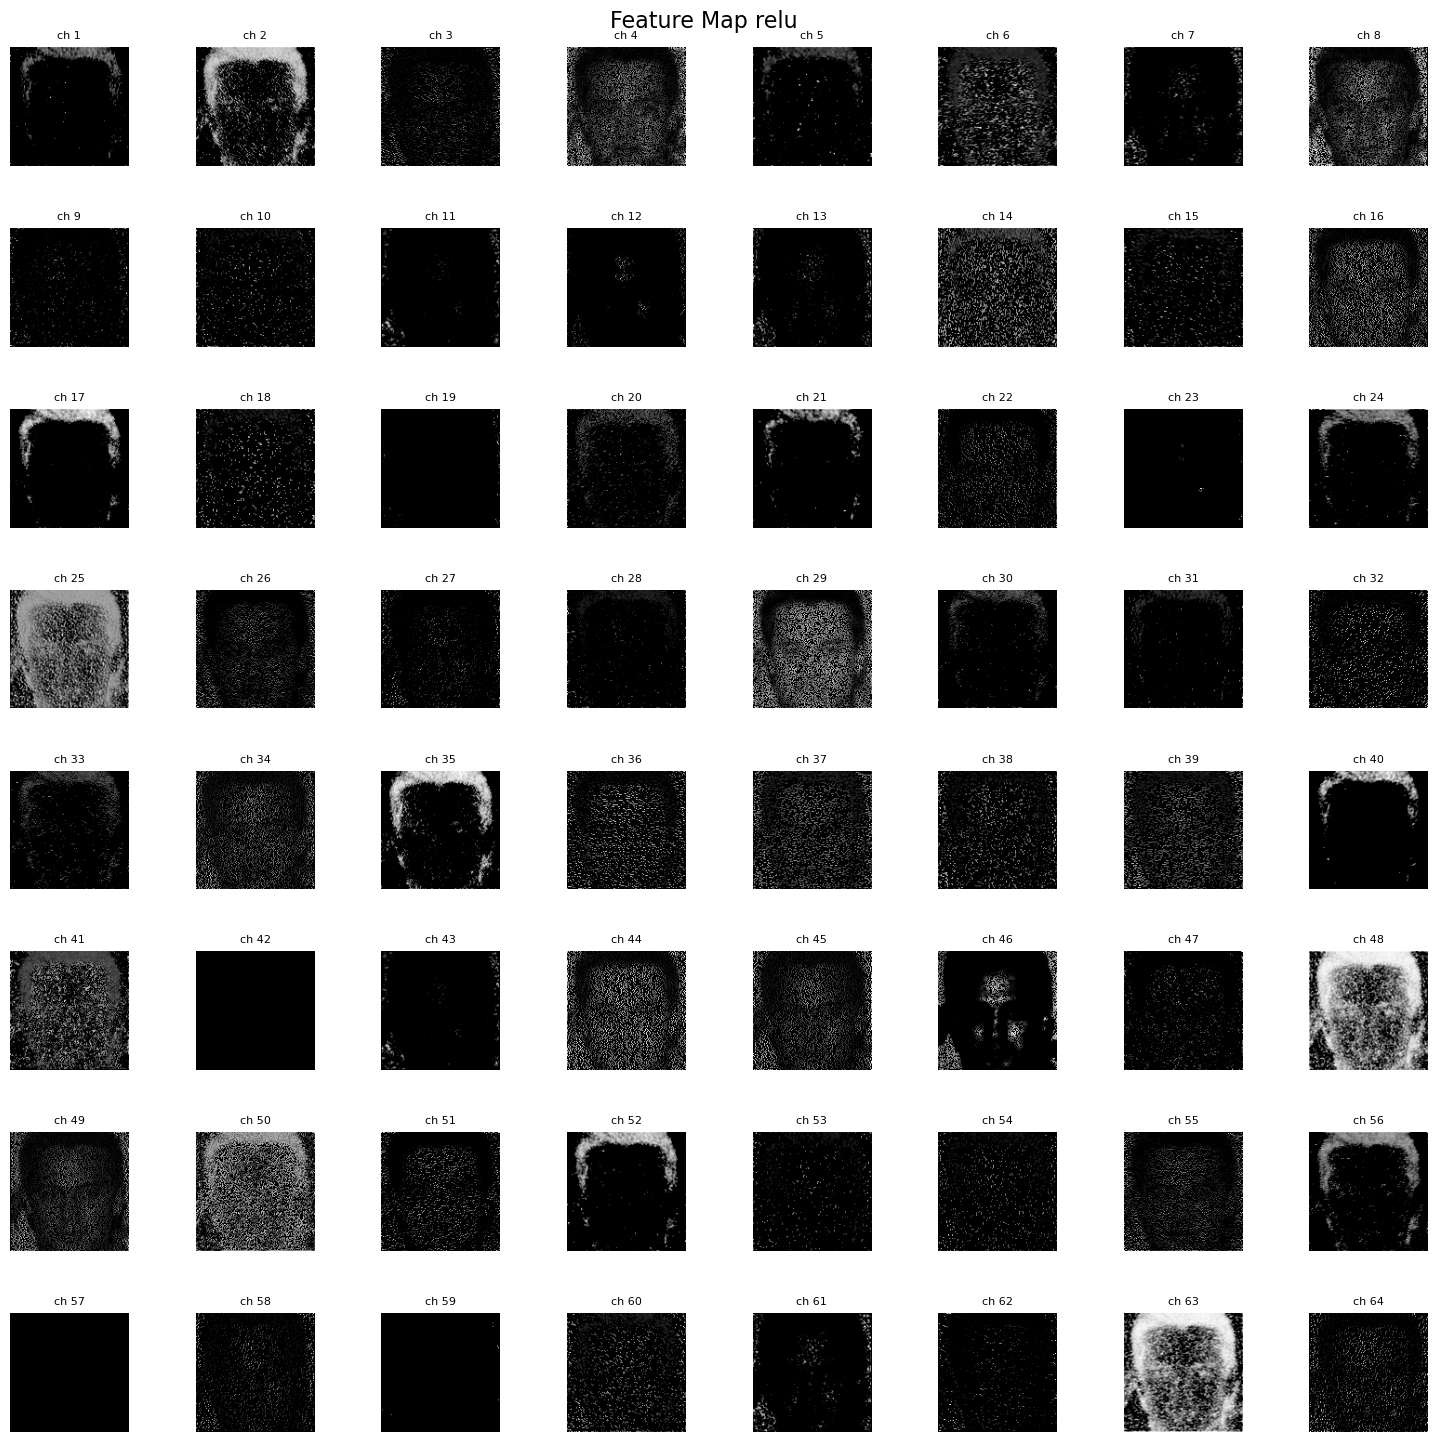

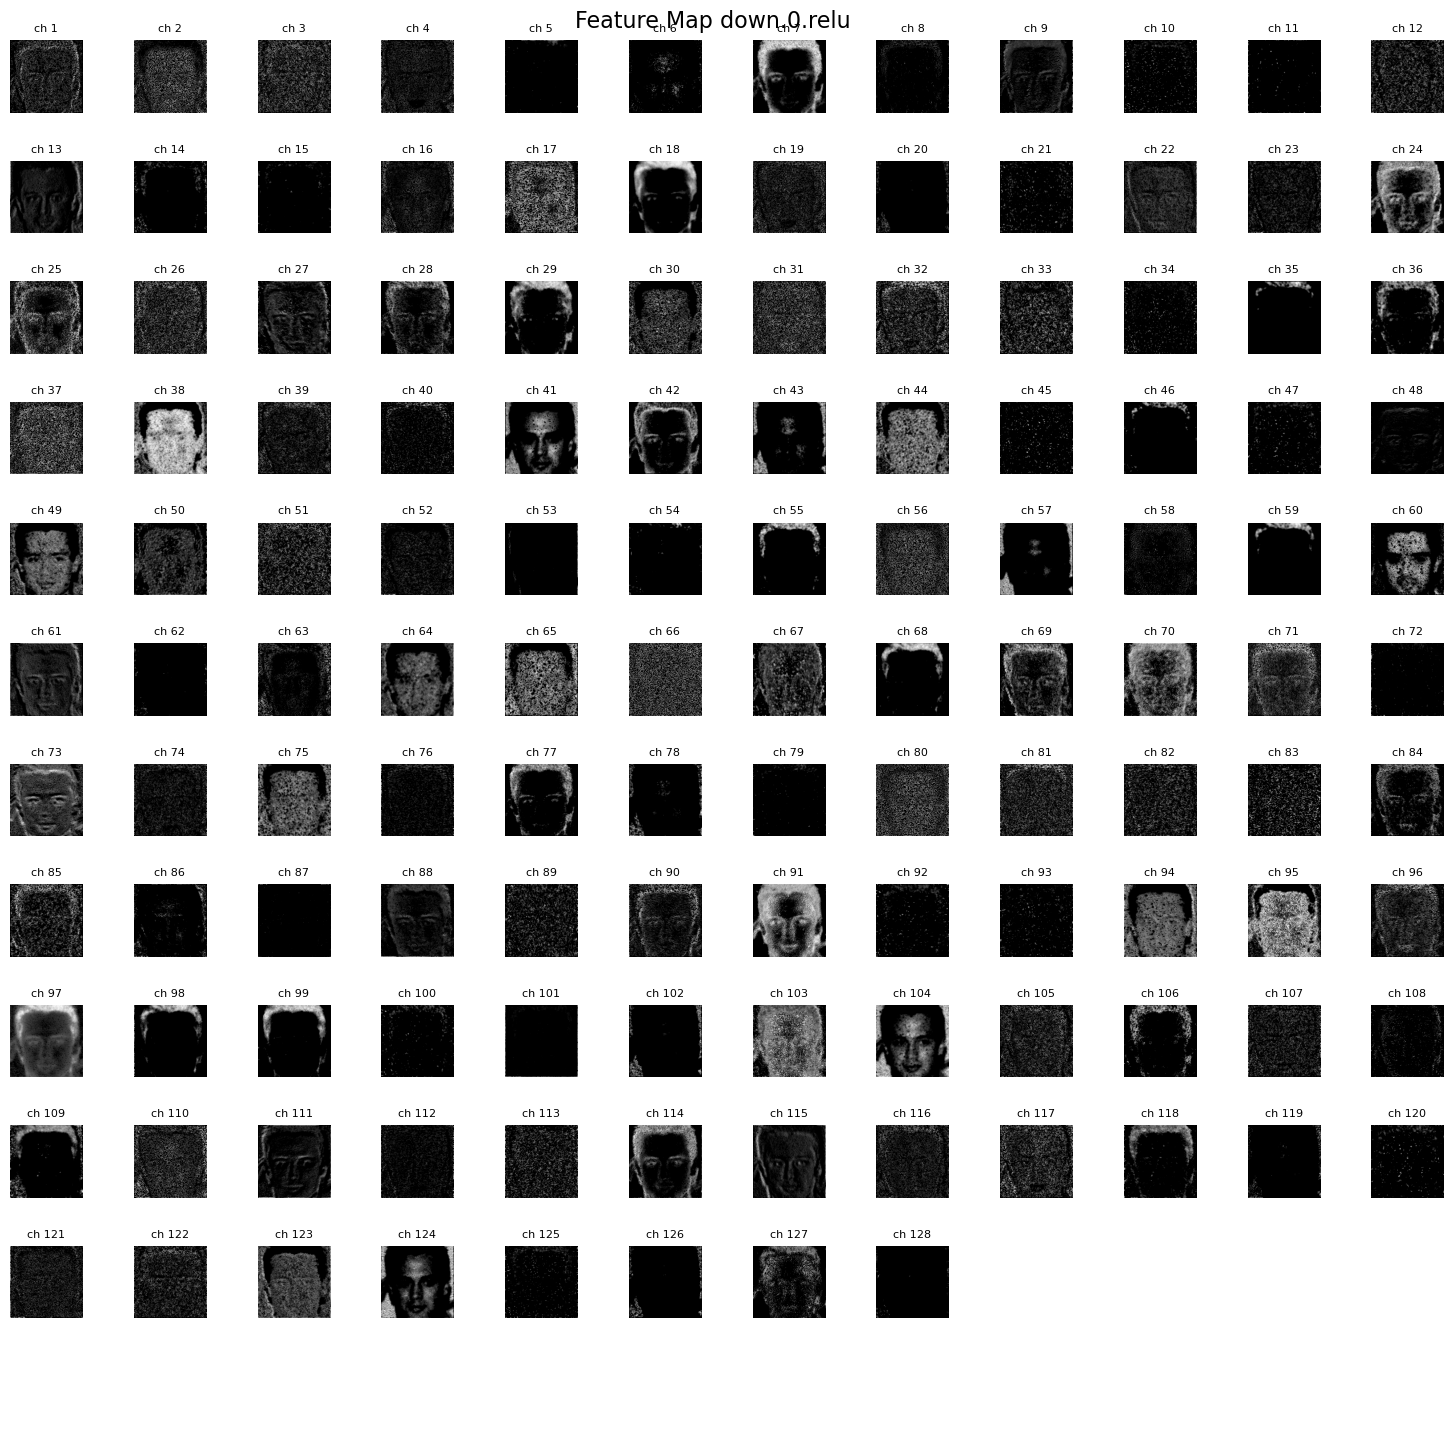

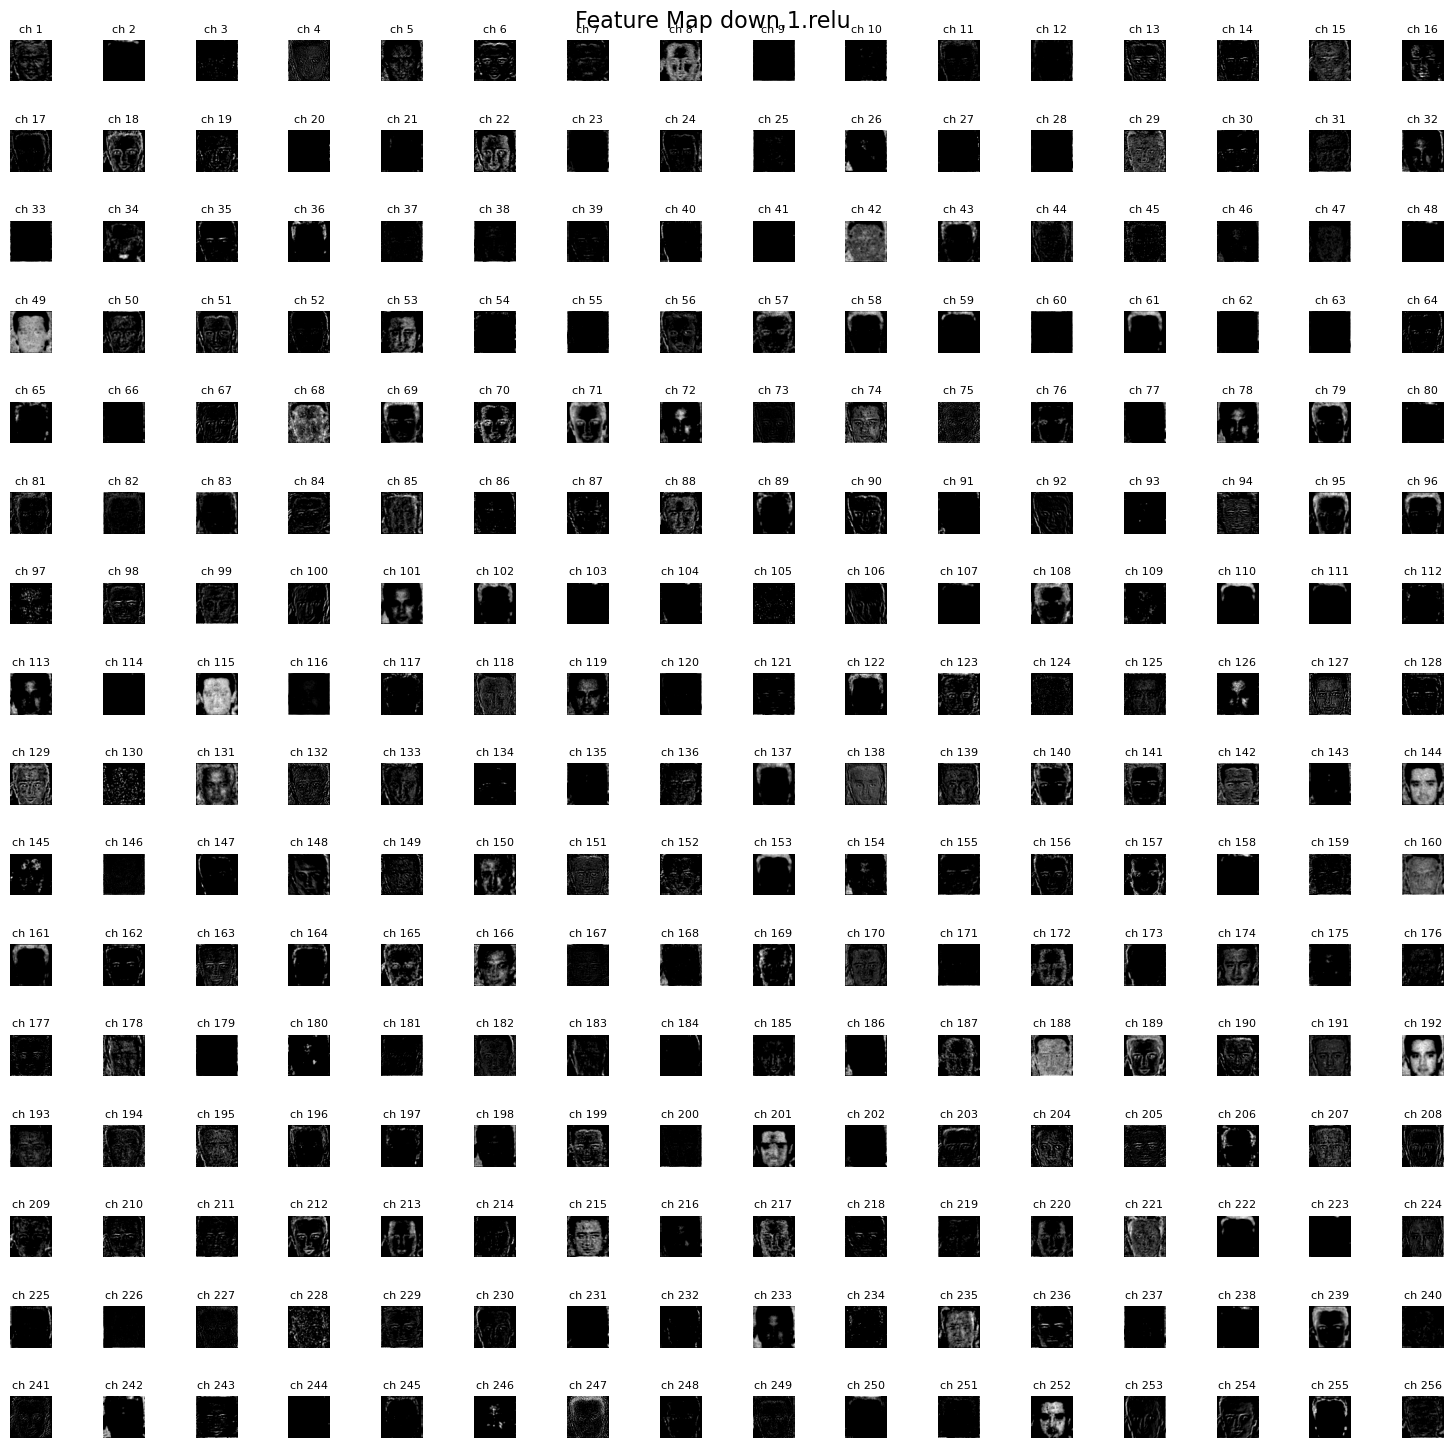

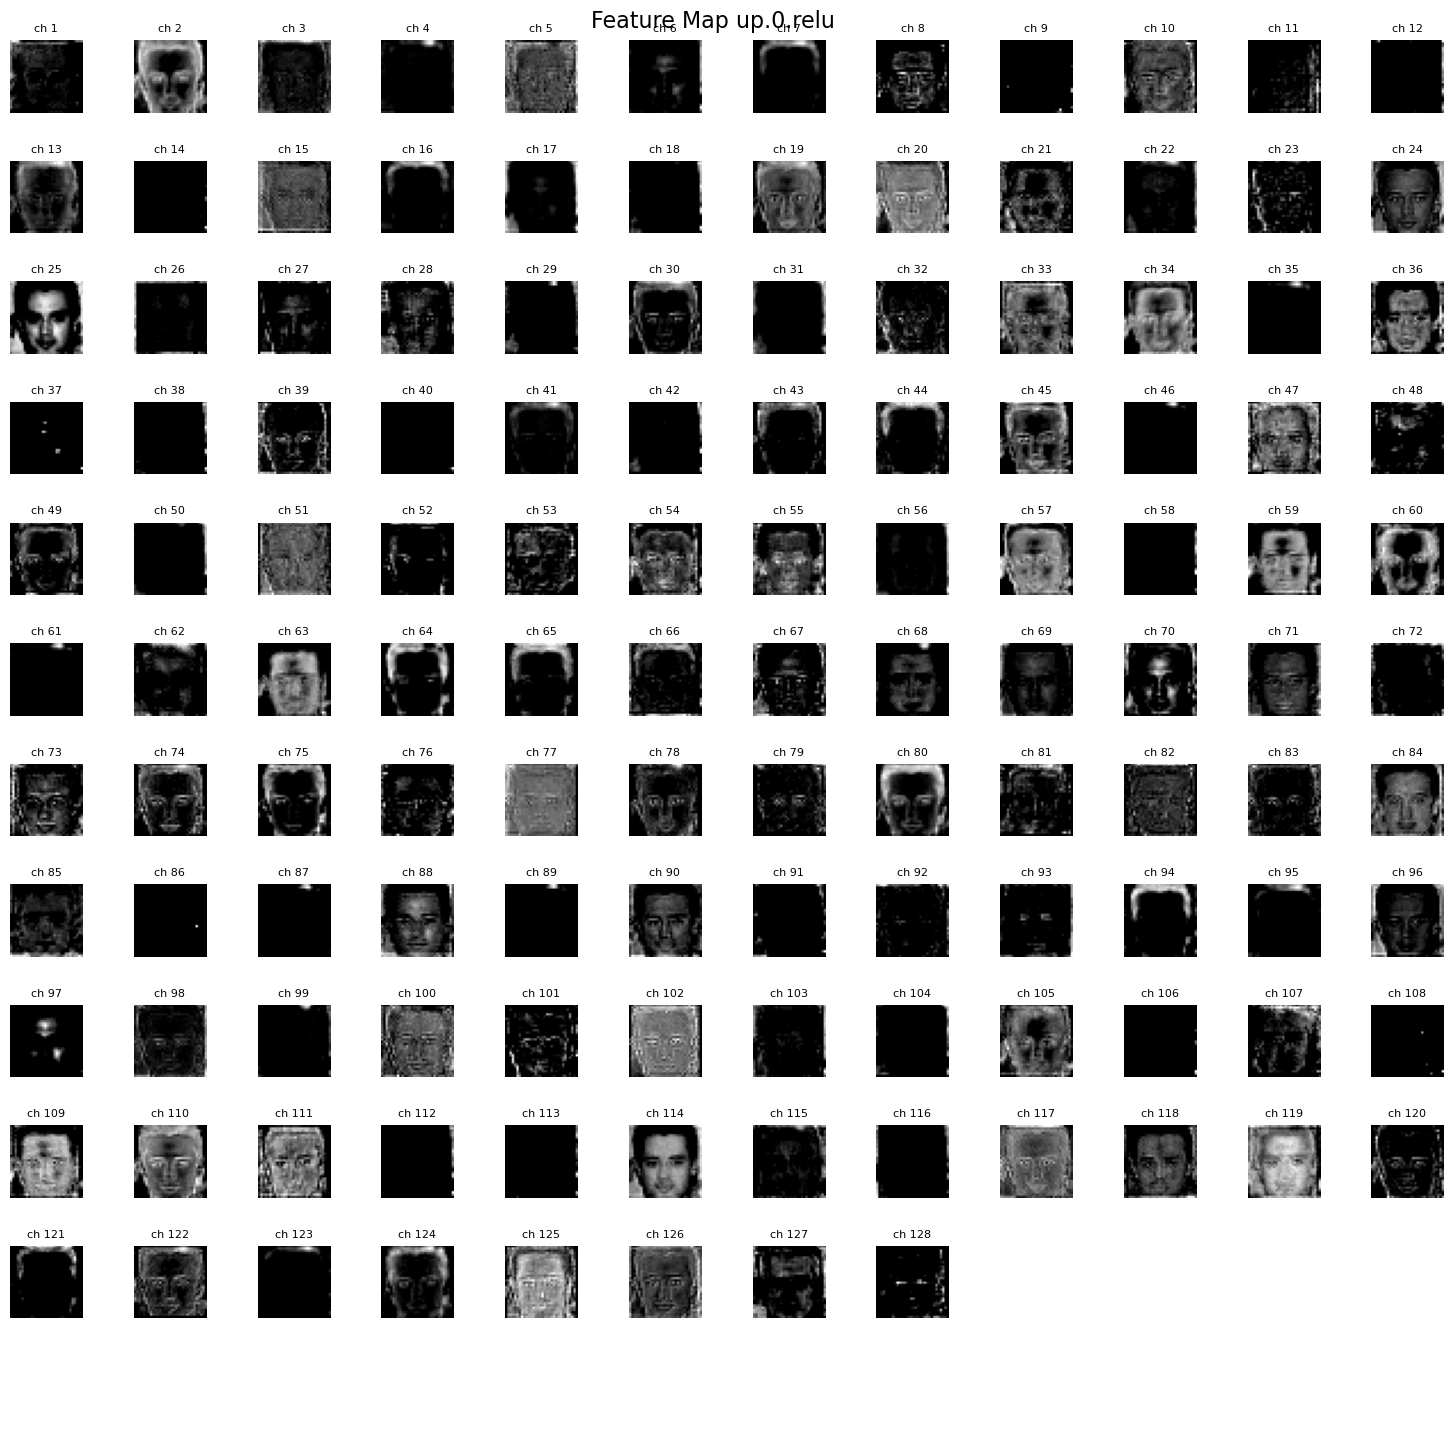

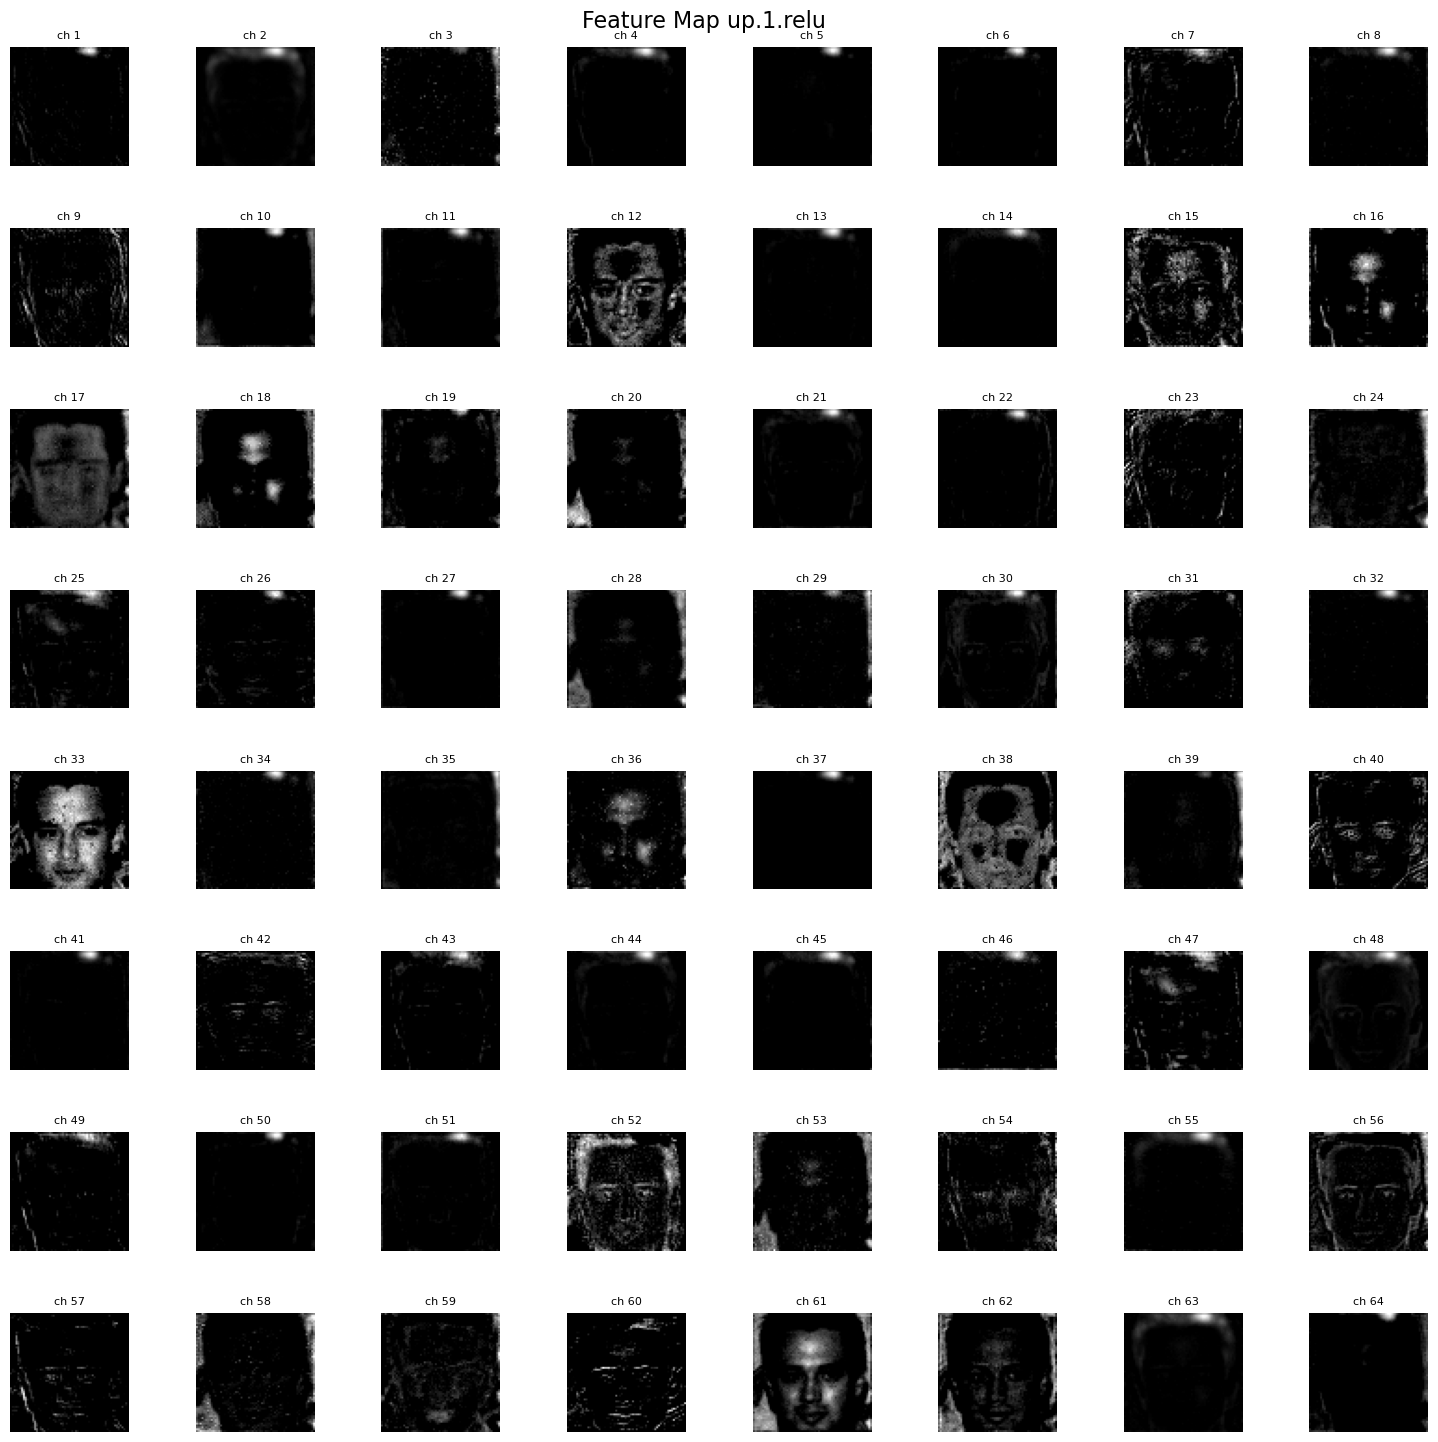

In [76]:
### START CODE HERE ###

layer = [name for name, layer in model.named_modules() if 'relu' in name]
visualizer = FeatureMapVisualizer(model, layer,
                                  "/home/crueang/Chaks/image_processing-2024/Lab6_Hyperparameter-Tuning/outputs/random_search/")
visualizer.visualize([batch])


### END CODE HERE ###

---

# Questions

1. How many combinations of hyperparameter values (trials) were evaluated during the hyperparameter tuning process?
<br>= grid_search 144 + random_search 80 = 224
2. What are the top 3 best parameters and their corresponding tuning results for the model?
### Grid Search

| val_psnr  | batch_size | optimizer | lr | num_epochs | architecture     |
|-----------|-------------------|------------------|-----------|-------------------|-------------------------|
| 29.518889 | 16         | Adam             | 0.0010    | 100               | [64, 128, 256, 512]      |
| 27.799257 | 16          | Adam             | 0.0008    | 50                | [64, 128, 256, 512]      |
| 27.527953 | 16          | Adam             | 0.0100    | 50                | [32, 64, 128]            |

### Random Search

| val_psnr  | batch_size        | optimizer        | lr         | num_epochs        | architecture             |
|-----------|-------------------|------------------|------------|-------------------|--------------------------|
| 28.895256 | 16                | Adam             | 0.000826   | 79                | [64, 128, 256]            |
| 28.793393 | 16                | Adam             | 0.002176   | 79                | [64, 128, 256]            |
| 28.677751 | 16                | Adam             | 0.002273   | 68                | [64, 128, 256, 512]       |
3. Analyze and compare the similarities and differences between the top 3 parameters in terms of model architecture, loss, performance, etc.
<br>  

